In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")
df_raw.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


Step 2: remove useless columns and empty rows

In [27]:
df = df_raw.copy()

# Drop empty trailing columns
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors="ignore")

# Drop fully empty rows
df = df.dropna(how="all")

print(df.shape)
df.head()

(9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Step 3: create one timestamp column

You need to combine Date and Time.

In [28]:
df["timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

In [29]:
cols = ["timestamp"] + [c for c in df.columns if c not in ["timestamp", "Date", "Time"]]
df = df[cols]
df.head()

,timestamp,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Step 4: sort by timestamp and reset index

In [30]:
df = df.sort_values("timestamp").reset_index(drop=True)

In [31]:
print("Missing timestamps:", df["timestamp"].isna().sum())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

Missing timestamps: 0
Duplicate timestamps: 0


In [32]:
(df == -200).sum().sort_values(ascending=False)

NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
C6H6(GT)          366
PT08.S1(CO)       366
PT08.S5(O3)       366
PT08.S2(NMHC)     366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
RH                366
T                 366
AH                366
timestamp           0
dtype: int64

In [33]:
df = df.replace(-200, np.nan)

In [34]:
missing_report = df.isna().sum().to_frame("missing_count")
missing_report["missing_rate"] = missing_report["missing_count"] / len(df)
missing_report.sort_values("missing_count", ascending=False)

,missing_count,missing_rate
NMHC(GT),8443,0.902319
CO(GT),1683,0.179865
NO2(GT),1642,0.175484
NOx(GT),1639,0.175163
C6H6(GT),366,0.039115
PT08.S1(CO),366,0.039115
PT08.S5(O3),366,0.039115
PT08.S2(NMHC),366,0.039115
PT08.S3(NOx),366,0.039115
PT08.S4(NO2),366,0.039115


In [35]:
df.to_csv("standardized_air_quality.csv", index=False)

In [36]:
validation_summary = []

for col in df.columns:
    if col == "timestamp":
        continue
    
    validation_summary.append({
        "column": col,
        "missing_count": df[col].isna().sum(),
        "missing_rate": df[col].isna().mean(),
        "min": df[col].min(),
        "max": df[col].max()
    })

validation_report = pd.DataFrame(validation_summary)
validation_report

,column,missing_count,missing_rate,min,max
0,CO(GT),1683,0.179865,0.1000,11.900
1,PT08.S1(CO),366,0.039115,647.0000,2040.000
2,NMHC(GT),8443,0.902319,7.0000,1189.000
3,C6H6(GT),366,0.039115,0.1000,63.700
4,PT08.S2(NMHC),366,0.039115,383.0000,2214.000
5,NOx(GT),1639,0.175163,2.0000,1479.000
6,PT08.S3(NOx),366,0.039115,322.0000,2683.000
7,NO2(GT),1642,0.175484,2.0000,340.000
8,PT08.S4(NO2),366,0.039115,551.0000,2775.000
9,PT08.S5(O3),366,0.039115,221.0000,2523.000


In [37]:
time_not_increasing = (df["timestamp"].diff().dropna() <= pd.Timedelta(0)).sum()
duplicate_timestamps = df["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)
print("Non-increasing timestamp steps:", time_not_increasing)

Duplicate timestamps: 0
Non-increasing timestamp steps: 0


In [38]:
validation_report.to_csv("validation_report.csv", index=False)

Step 8 repair

In [39]:
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

# Interpolate first
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method="linear")

# Then forward fill / backward fill for edges
df_clean[numeric_cols] = df_clean[numeric_cols].ffill().bfill()

In [40]:
repair_log = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    outlier_count = outlier_mask.sum()
    
    # clip values
    df_clean[col] = df_clean[col].clip(lower, upper)
    
    repair_log.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers_repaired": int(outlier_count)
    })

repair_log_df = pd.DataFrame(repair_log)
repair_log_df

,column,lower_bound,upper_bound,outliers_repaired
0,CO(GT),-1.600000,5.600000,224
1,PT08.S1(CO),486.500000,1690.500000,103
2,NMHC(GT),275.000000,275.000000,1229
3,C6H6(GT),-9.900000,28.500000,242
4,PT08.S2(NMHC),161.500000,1693.500000,64
5,NOx(GT),-249.000000,671.000000,432
6,PT08.S3(NOx),183.000000,1439.000000,239
7,NO2(GT),-14.472028,226.786713,165
8,PT08.S4(NO2),565.500000,2329.500000,108
9,PT08.S5(O3),-107.000000,2133.000000,71


In [41]:
df_clean.to_csv("cleaned_air_quality.csv", index=False)
repair_log_df.to_csv("repair_log.csv", index=False)

In [42]:
comparison = []

for col in numeric_cols:
    comparison.append({
        "column": col,
        "raw_missing": df[col].isna().sum(),
        "clean_missing": df_clean[col].isna().sum(),
        "raw_min": df[col].min(),
        "clean_min": df_clean[col].min(),
        "raw_max": df[col].max(),
        "clean_max": df_clean[col].max()
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,column,raw_missing,clean_missing,raw_min,clean_min,raw_max,clean_max
0,CO(GT),1683,0,0.1000,0.1000,11.900,5.600000
1,PT08.S1(CO),366,0,647.0000,647.0000,2040.000,1690.500000
2,NMHC(GT),8443,0,7.0000,275.0000,1189.000,275.000000
3,C6H6(GT),366,0,0.1000,0.1000,63.700,28.500000
4,PT08.S2(NMHC),366,0,383.0000,383.0000,2214.000,1693.500000
5,NOx(GT),1639,0,2.0000,2.0000,1479.000,671.000000
6,PT08.S3(NOx),366,0,322.0000,322.0000,2683.000,1439.000000
7,NO2(GT),1642,0,2.0000,2.0000,340.000,226.786713
8,PT08.S4(NO2),366,0,551.0000,565.5000,2775.000,2329.500000
9,PT08.S5(O3),366,0,221.0000,221.0000,2523.000,2133.000000


In [43]:
comparison_df.to_csv("quality_comparison.csv", index=False)

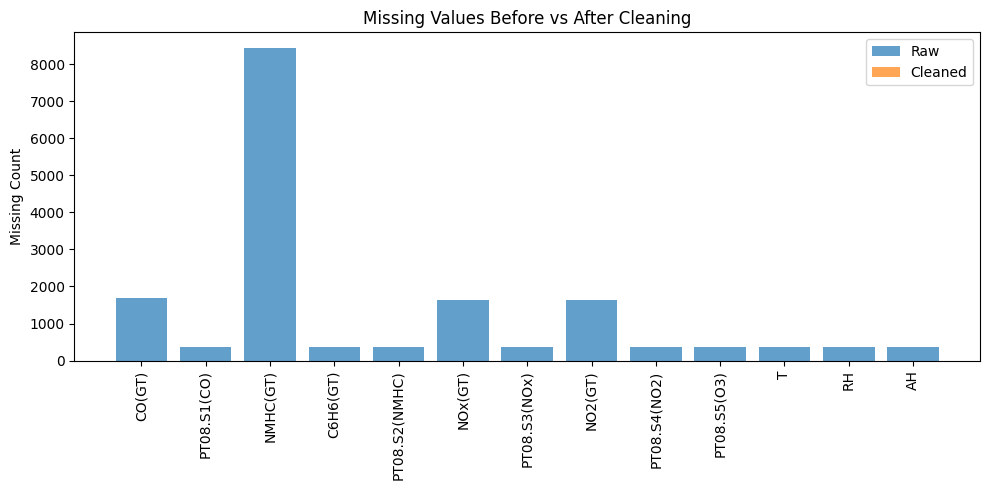

In [44]:
plt.figure(figsize=(10, 5))
plt.bar(comparison_df["column"], comparison_df["raw_missing"], alpha=0.7, label="Raw")
plt.bar(comparison_df["column"], comparison_df["clean_missing"], alpha=0.7, label="Cleaned")
plt.xticks(rotation=90)
plt.ylabel("Missing Count")
plt.title("Missing Values Before vs After Cleaning")
plt.legend()
plt.tight_layout()
plt.show()

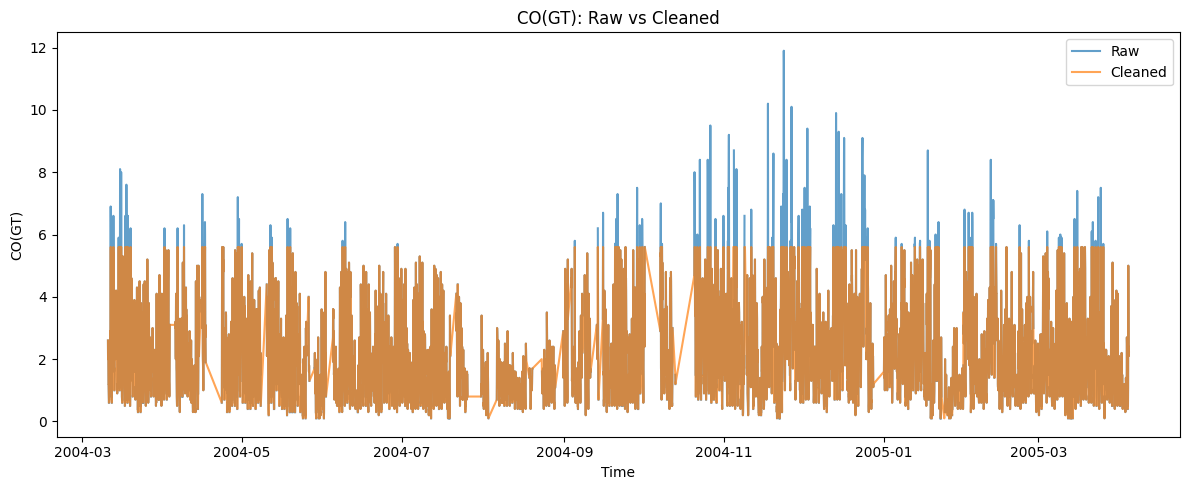

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["CO(GT)"], label="Raw", alpha=0.7)
plt.plot(df_clean["timestamp"], df_clean["CO(GT)"], label="Cleaned", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("CO(GT)")
plt.title("CO(GT): Raw vs Cleaned")
plt.legend()
plt.tight_layout()
plt.show()

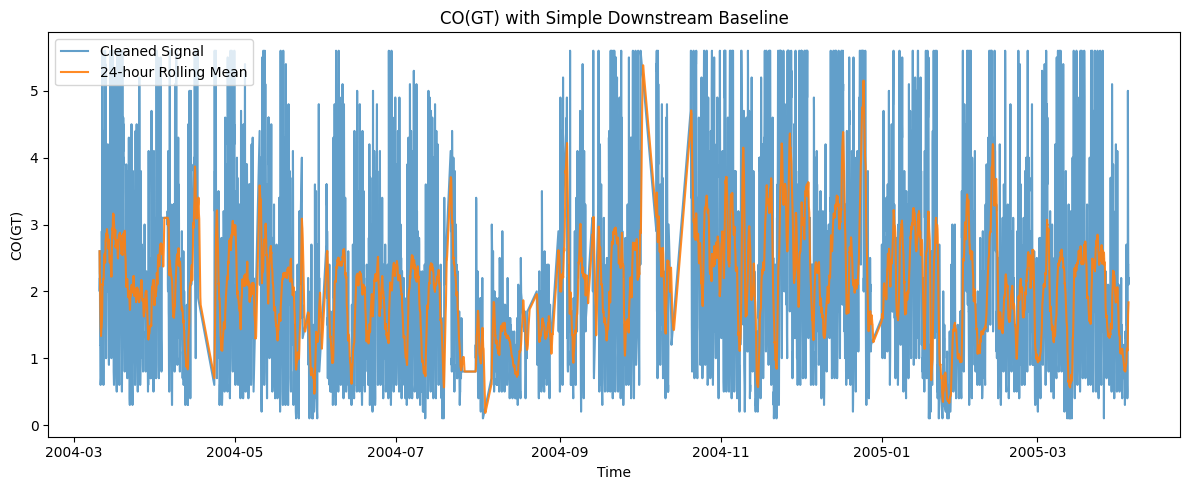

In [46]:
sensor_col = "CO(GT)"

df_eval = df_clean[["timestamp", sensor_col]].copy()
df_eval["rolling_mean_24"] = df_eval[sensor_col].rolling(window=24, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_eval["timestamp"], df_eval[sensor_col], label="Cleaned Signal", alpha=0.7)
plt.plot(df_eval["timestamp"], df_eval["rolling_mean_24"], label="24-hour Rolling Mean", alpha=0.9)
plt.xlabel("Time")
plt.ylabel(sensor_col)
plt.title(f"{sensor_col} with Simple Downstream Baseline")
plt.legend()
plt.tight_layout()
plt.show()